In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
with open('data_description.txt', 'r') as file:
  print(file.read())

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [3]:
train = pd.read_csv('train.csv')

In [4]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
train.shape

(1460, 81)

In [6]:
test = pd.read_csv('test.csv')

In [7]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [8]:
sub = pd.read_csv('sample_submission.csv')

In [9]:
sub = sub.drop('Id', axis=1)

In [10]:
test = pd.concat([test, sub], axis=1)

In [11]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,169277.052498
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,187758.393989
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,183583.683570
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,179317.477511
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,150730.079977


In [12]:
df = pd.concat([train, test], axis=0)

In [13]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [14]:
df.shape

(2919, 81)

In [15]:
def manquante(df):
  manq = 100*df.isnull().sum()/len(df)
  manq = manq[manq>0].sort_values(ascending=True)
  return manq

In [16]:
manquante(df)

,0
Exterior2nd,0.034258
Exterior1st,0.034258
BsmtUnfSF,0.034258
BsmtFinSF2,0.034258
BsmtFinSF1,0.034258
KitchenQual,0.034258
Electrical,0.034258
TotalBsmtSF,0.034258
GarageArea,0.034258
GarageCars,0.034258


In [17]:
df = df.drop(['Id', 'Fence', 'Alley', 'MiscFeature', 'PoolQC'], axis=1)

In [18]:
manquante(df)

,0
Exterior1st,0.034258
Exterior2nd,0.034258
TotalBsmtSF,0.034258
BsmtFinSF1,0.034258
BsmtFinSF2,0.034258
BsmtUnfSF,0.034258
KitchenQual,0.034258
Electrical,0.034258
GarageCars,0.034258
GarageArea,0.034258


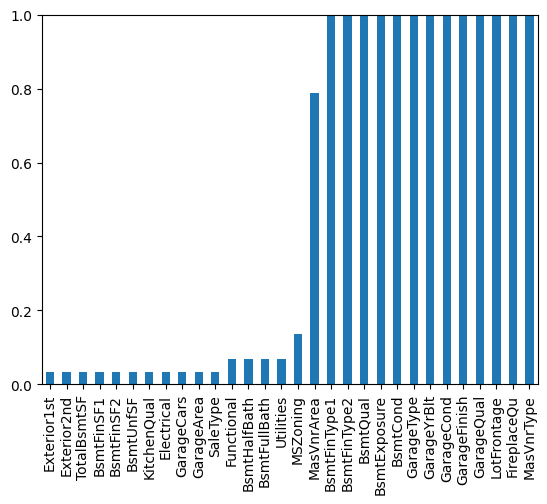

In [19]:
manquante(df).plot(kind='bar')
plt.ylim(0, 1);

In [20]:
df['Electrical'].value_counts()

,count
Electrical,
SBrkr,2671
FuseA,188
FuseF,50
FuseP,8
Mix,1


In [21]:
df['Electrical'] = df['Electrical'].fillna('SBrkr')

In [22]:
manquante(df)

,0
Exterior1st,0.034258
Exterior2nd,0.034258
TotalBsmtSF,0.034258
BsmtFinSF1,0.034258
BsmtFinSF2,0.034258
BsmtUnfSF,0.034258
SaleType,0.034258
KitchenQual,0.034258
GarageCars,0.034258
GarageArea,0.034258


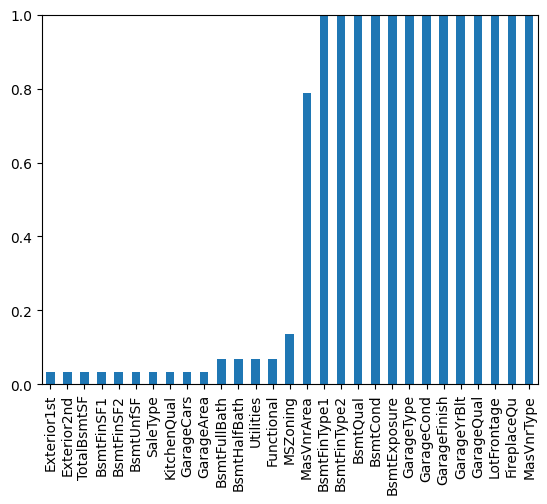

In [23]:
manquante(df).plot(kind='bar')
plt.ylim(0, 1);

In [24]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0.0)

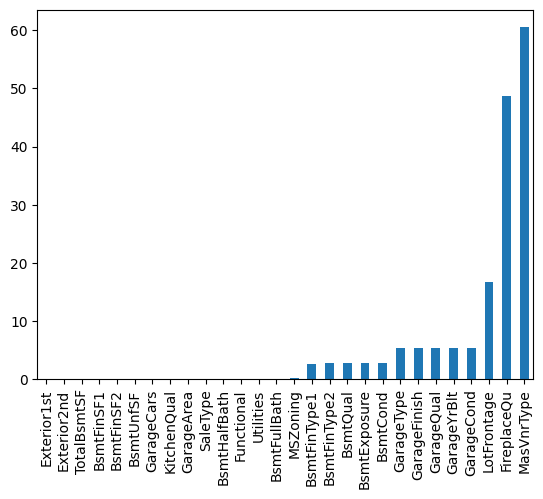

In [25]:
manquante(df).plot(kind='bar');

In [26]:
val = ['BsmtCond', 'BsmtQual', 'BsmtExposure', 'BsmtFinType1',
 'BsmtFinType2', 'GarageFinish', 'GarageType', 'GarageCond',
 'GarageQual', 'MasVnrType']

In [27]:
df[val] = df[val].fillna('None')

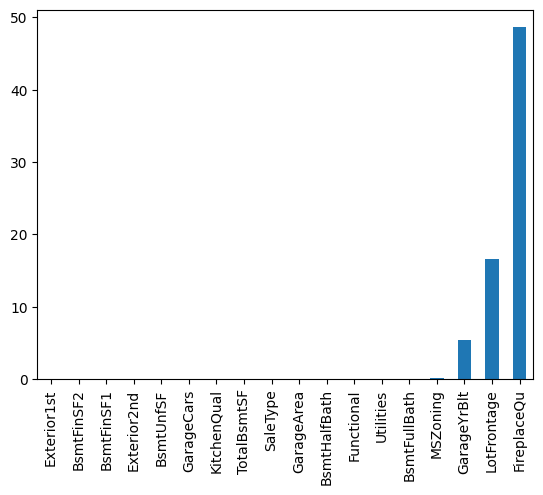

In [28]:
manquante(df).plot(kind='bar');

In [29]:
df['FireplaceQu'] = df['FireplaceQu'].fillna('None')

In [30]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

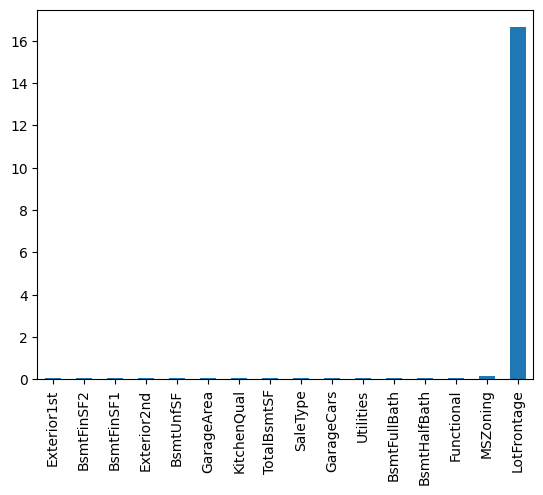

In [31]:
manquante(df).plot(kind='bar');

In [32]:
df.groupby('Neighborhood')['LotFrontage'].median()

,LotFrontage
Neighborhood,
Blmngtn,43.0
Blueste,24.0
BrDale,21.0
BrkSide,51.0
ClearCr,80.5
CollgCr,70.0
Crawfor,70.0
Edwards,65.0
Gilbert,64.0


In [33]:
df['LotFrontage'] = df['LotFrontage'].fillna(df.groupby('Neighborhood')['LotFrontage'].transform('median'))

In [34]:
manquante(df)

,0
Exterior2nd,0.034258
Exterior1st,0.034258
BsmtFinSF2,0.034258
BsmtFinSF1,0.034258
BsmtUnfSF,0.034258
TotalBsmtSF,0.034258
SaleType,0.034258
KitchenQual,0.034258
GarageArea,0.034258
GarageCars,0.034258


In [35]:
df = df.dropna(axis=0)

In [36]:
manquante(df)

,0


In [37]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500.0
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500.0
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500.0
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000.0
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000.0


In [38]:
df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=True)

,SalePrice
MSSubClass,-0.087409
KitchenAbvGr,-0.071531
EnclosedPorch,-0.071508
OverallCond,-0.063318
YrSold,-0.038862
LowQualFinSF,-0.015359
BsmtHalfBath,-0.012356
BsmtFinSF2,-0.007404
MiscVal,-0.000226
3SsnPorch,0.030182


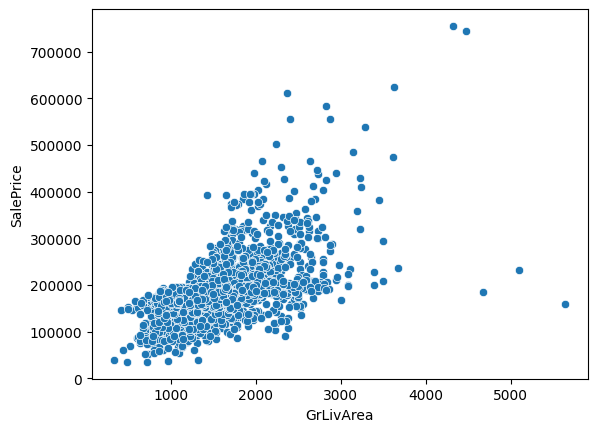

In [40]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df);

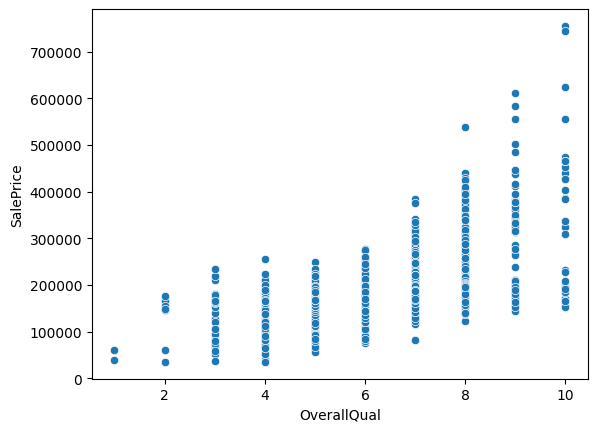

In [41]:
sns.scatterplot(x='OverallQual', y='SalePrice', data=df);

In [42]:
df[(df['GrLivArea']>4000)&(df['SalePrice']<300000)]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,60,RL,130.0,40094,Pave,IR1,Bnk,AllPub,Inside,Gtl,...,0,0,0,0,0,10,2007,New,Partial,184750.000000
1298,60,RL,313.0,63887,Pave,IR3,Bnk,AllPub,Corner,Gtl,...,0,0,0,480,0,1,2008,New,Partial,160000.000000
1089,20,RL,128.0,39290,Pave,IR1,Bnk,AllPub,Inside,Gtl,...,0,0,0,0,17000,10,2007,New,Partial,230841.338626


In [43]:
df = df.drop([53, 1298, 1089], axis=0)

In [44]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500.0
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500.0
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500.0
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000.0
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000.0


In [45]:
num = df.select_dtypes(exclude='object')
objet = df.select_dtypes(include='object')

In [46]:
dumies = pd.get_dummies(objet, drop_first=True)

In [47]:
df_final = pd.concat([dumies, num], axis=1)

In [48]:
df_final.head()

,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,False,False,True,False,True,False,False,True,False,False,...,0,61,0,0,0,0,0,2,2008,208500.0
1,False,False,True,False,True,False,False,True,False,False,...,298,0,0,0,0,0,0,5,2007,181500.0
2,False,False,True,False,True,False,False,False,False,False,...,0,42,0,0,0,0,0,9,2008,223500.0
3,False,False,True,False,True,False,False,False,False,False,...,0,35,272,0,0,0,0,2,2006,140000.0
4,False,False,True,False,True,False,False,False,False,False,...,192,84,0,0,0,0,0,12,2008,250000.0


In [49]:
df_final.shape

(2901, 246)

In [50]:
X = df_final.drop('SalePrice', axis=1)
y = df_final['SalePrice']

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
from sklearn.preprocessing import StandardScaler

In [54]:
scaler = StandardScaler()

In [55]:
scale_X_train = scaler.fit_transform(X_train)
scale_X_test = scaler.transform(X_test)

#Regression logistique

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [57]:
lr = LinearRegression()

In [58]:
lr.fit(scale_X_train, y_train)

LinearRegression()

In [59]:
y_pred = lr.predict(scale_X_test)

In [60]:
score_lr = r2_score(y_test, y_pred)

In [61]:
score_lr

0.4399597243089053

#Forêt aléatoire



In [62]:
from sklearn.ensemble import RandomForestRegressor

In [63]:
rf = RandomForestRegressor()

In [64]:
rf.fit(X_train, y_train)

RandomForestRegressor()

In [65]:
y_pred = rf.predict(X_test)

In [66]:
score_rf = r2_score(y_test, y_pred)

In [67]:
score_rf

0.5017627992664738

#XGBoost

In [68]:
from xgboost import XGBRegressor

In [69]:
xgb = XGBRegressor()

In [70]:
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [71]:
y_pred = xgb.predict(X_test)

In [72]:
score_xgb = r2_score(y_test, y_pred)

In [73]:
score_xgb

0.4157856843273665

In [74]:
importance_df = pd.DataFrame(
    xgb.feature_importances_,
    index=X.columns,
    columns=['Importance']
).sort_values(by='Importance', ascending=False)

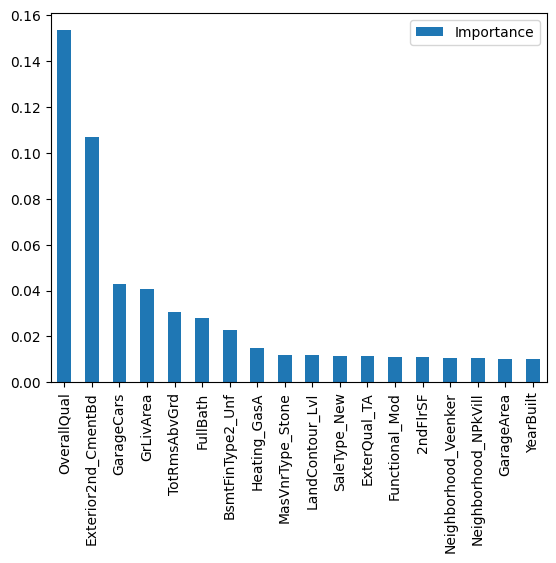

In [75]:
importance_df[importance_df['Importance']>0.01].plot(kind='bar');

In [76]:
import shap

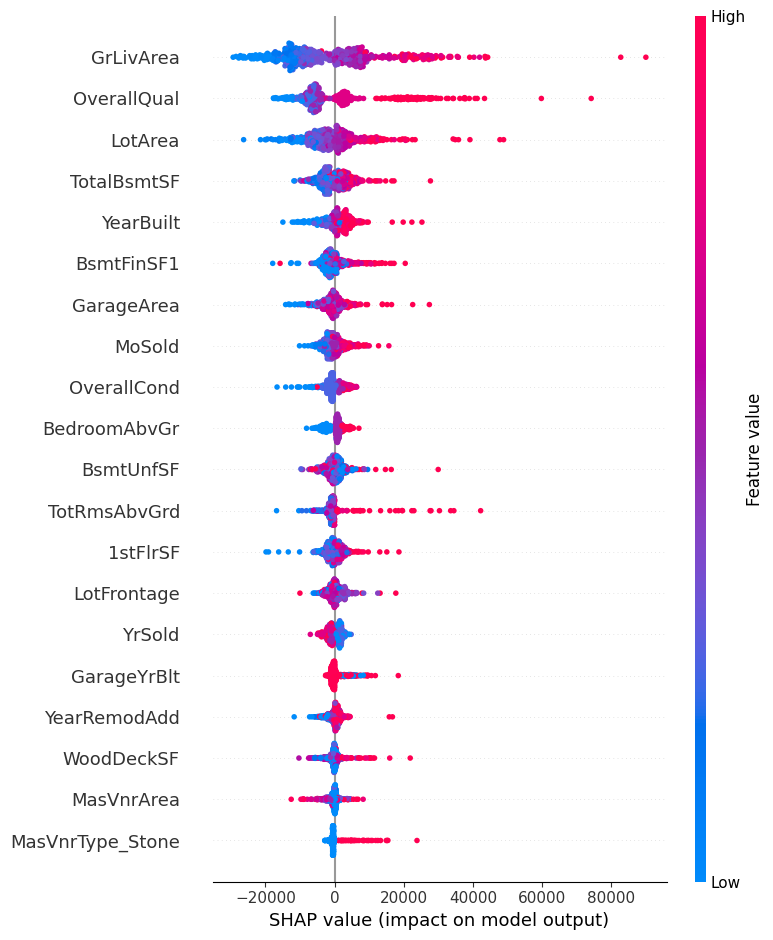

In [77]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test);

#LigthGBM

In [78]:
from lightgbm import LGBMRegressor

In [79]:
lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8
)

In [80]:
lgb_model.fit(X_train,y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002444 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3709
[LightGBM] [Info] Number of data points in the train set: 2320, number of used features: 178
[LightGBM] [Info] Start training from score 179953.446956


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
              subsample=0.8)

In [81]:
y_pred = lgb_model.predict(X_test)

In [82]:
lgb_score = r2_score(y_test, y_pred)

In [83]:
lgb_score

0.48700236116987516

In [84]:
feat = pd.DataFrame(
    lgb_model.feature_importances_,
    index=X.columns,
    columns=['Importance']
).sort_values(by='Importance', ascending=False)

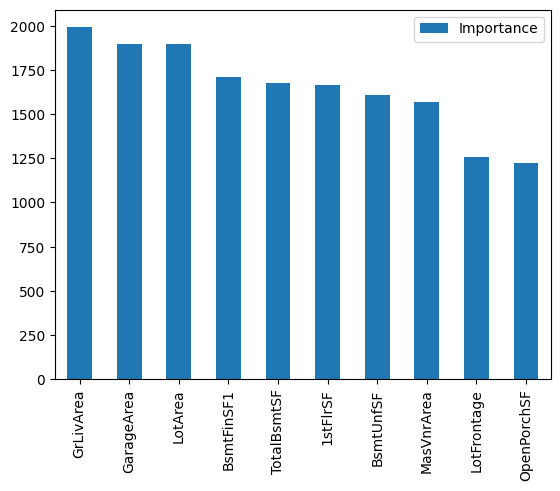

In [85]:
feat[feat['Importance']>0].head(10).plot(kind='bar');

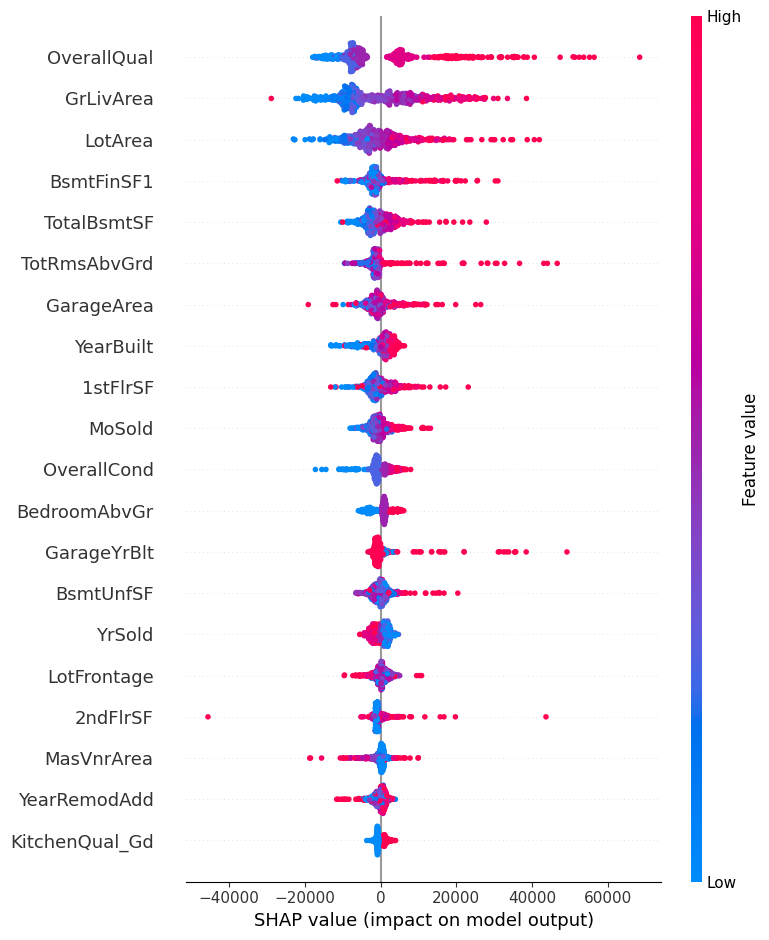

In [86]:
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test);

#Test de mon modèle avec RandomForest

In [87]:
test = X_test.iloc[24]

In [88]:
test = test.values.reshape(1, -1)

In [89]:
np.round(rf.predict(test), 1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([175249.2])

In [90]:
y_test.iloc[24]

np.float64(152000.0)

#Essayons un ANNs

In [91]:
X = df_final.drop('SalePrice', axis=1).values
y = df_final['SalePrice'].values

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [93]:
from sklearn.preprocessing import MinMaxScaler

In [94]:
scale = MinMaxScaler()

In [95]:
X_scale_train = scale.fit_transform(X_train)
X_scale_test = scale.transform(X_test)

In [96]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [97]:
model = Sequential()

model.add(Dense(300, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(150, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1))

In [98]:
model.compile(optimizer='adam', loss='mse')

In [99]:
stop = EarlyStopping(monitor='loss', mode='min', verbose=1, patience=20)

In [100]:
model.fit(X_scale_train, y_train, epochs=200, validation_data=(X_scale_test, y_test), callbacks=[stop], batch_size=32)

Epoch 1/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 34493550592.0000 - val_loss: 35749855232.0000
Epoch 2/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 35504066560.0000 - val_loss: 33026537472.0000
Epoch 3/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 32209305600.0000 - val_loss: 24949092352.0000
Epoch 4/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 20944592896.0000 - val_loss: 12982675456.0000
Epoch 5/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 10030394368.0000 - val_loss: 4807216640.0000
Epoch 6/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3699251200.0000 - val_loss: 2996272640.0000
Epoch 7/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 3037791744.0000 - val_loss: 2807905024.0000
Epoch 8/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2783342592.0000 - val_loss: 2715942400.0000
Epoch 9/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2459023104.0000 - val_loss: 2638603264.0000
Epoch 10/200
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - los

In [101]:
loss = pd.DataFrame(model.history.history)

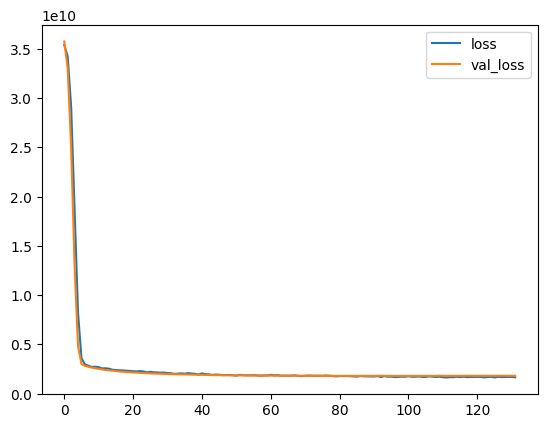

In [103]:
loss.plot();

In [104]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │        73,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 150)            │        45,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           151 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,305 (1.36 MB)

 Trainable params: 119,101 (465.24 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 238,204 (930.49 KB)

In [107]:
y_pred = model.predict(X_scale_test)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [108]:
r2_score(y_test, y_pred)

0.45824314523358733

***Test avec le ANNs***

In [114]:
test = X_test[825]

In [115]:
test = scale.transform(test.reshape(1, -1))

In [116]:
model.predict(test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


array([[181779.34]], dtype=float32)

In [118]:
y_test[825]

np.float64(165500.0)

In [111]:
model.save('model_house.h5')